In [7]:
import numpy as np
import meep as mp
import matplotlib.pyplot as plt
from nanoantenna import make_triangle



In [8]:
#### Cell Parameters ####
resolution = 100
pml = .2
sx  = .8
sy = .8
sz = 1.2
cell = mp.Vector3(sx, sy, sz)
boundary_layers = [mp.PML(pml)]


In [9]:
#### Nanoantenna Geometry ###
from meep.materials import SiO2
from meep.materials import Au
from meep.materials import Au_JC_visible

print(Au.valid_freq_range)
print(SiO2.valid_freq_range)

#### Antenna ####

a = 0.2
b = .1
thickness = .02
center = mp.Vector3(0,0,thickness/2)
theta_rot = np.pi/2
r_curvature = 0.01
antenna_mat = Au

geometry  = make_triangle(a, b, r_curvature, thickness, center, antenna_mat, theta_rot)

#### Substrate ####

geometry.append(mp.Block(
    center = mp.Vector3(0, 0, (-sz/2 + pml)/2),
    size = mp.Vector3(mp.inf, mp.inf, sz/2 - pml),
    material = SiO2
))



FreqRange(min=0.16131113692089302, max=4.0327458966810505)
FreqRange(min=0.5649717514124294, max=4.0)


In [10]:
### Optical Excitation ###
lam = .8
fcen = 1/lam #(1/um)


fwhm_fs = 100                       
fwhm_um = fwhm_fs / 3.33          
sigma_um = fwhm_um / 2.355         
df = 1 / (2 * np.pi * sigma_um)     

fcen = 1 / lam
sources = [mp.Source(mp.GaussianSource(frequency=fcen, fwidth = df, is_integrated = True), 
                     component = mp.Ex,
                     center = mp.Vector3(0,0,sz/2-pml),
                     size = mp.Vector3(sx, sy, 0))]



In [11]:
sim = mp.Simulation(
    cell_size=cell,
    boundary_layers=boundary_layers,
    geometry=geometry,
    sources=sources,
    resolution=resolution,
    default_material=mp.air,
)


In [ ]:

vol_xy = mp.Volume(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, sy, 0))  # x-y at z=0
vol_xz = mp.Volume(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sx, 0, sz))  # x-y at z=0

Ecomps = [mp.Ex, mp.Ey, mp.Ez]

frames = {"t": [], "xy": {c: [] for c in Ecomps}, "xz": {c: [] for c in Ecomps}}

frame_dt = 2.0

def grab_frame(sim):
    frames["t"].append(sim.meep_time())
    for c in Ecomps:
        frames["xy"][c].append(sim.get_array(vol=vol_xy, component=c))
        frames["xz"][c].append(sim.get_array(vol=vol_xz, component=c))


sim.run(mp.at_every(frame_dt, grab_frame), until=200)

# Save time array
np.save("frames_t.npy", np.array(frames["t"]))

# Save field arrays
for plane in ["xy", "xz"]:
    for c in Ecomps:
        np.save(f"frames_{plane}_{c}.npy", np.array(frames[plane][c]))


-----------
Initializing structure...
time for choose_chunkdivision = 0.00190187 s
Working in 3D dimensions.
Computational cell is 0.8 x 0.8 x 1.2 with resolution 100
     prism, center = (0.00378732,0,0.01)
          height 0.02, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (0.0843845,-0.05,0)
          (-0.0768098,-0.00970143,0)
          (-0.0768098,0.00970143,0)
          (0.0843845,0.05,0)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-0.0743845,4.55474e-18,0.01)
          radius 0.01, height 0.02, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,-0.2)
          size (1e+20,1e+20,0.4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 2.72385 s
lorentzian susceptibility: frequency=9.67865, gamma=0.0806554
lorentzian susceptibility: frequency=10.7433, gamma=1.78571
lorentzian susceptibility: frequency=3.47141, g

In [ ]:
cal_sim = mp.Simulation(
    cell_size=cell,
    boundary_layers=boundary_layers,
    geometry=[],
    sources=sources,
    resolution=50,
    default_material=mp.air,
)

cal_vol_xy = mp.Volume(center=mp.Vector3(0, 0, thickness), size=mp.Vector3(sx/2, sy/2, 0))  
cal_frames = {"t": [], "xy": {c: [] for c in Ecomps}}

frame_dt = 2.0

def cal_grab_frame(cal_sim):
    cal_frames["t"].append(cal_sim.meep_time())
    for c in Ecomps:
        cal_frames["xy"][c].append(cal_sim.get_array(vol=cal_vol_xy, component=c))


cal_sim.run(mp.at_every(frame_dt, cal_grab_frame), until=200)

comp = [0,1,4]
vmax_cal = max(np.max(cal_frames["xy"][c]) for c in comp)


-----------
Initializing structure...
time for choose_chunkdivision = 0.000308037 s
Working in 3D dimensions.
Computational cell is 1 x 1 x 0.6 with resolution 50
time for set_epsilon = 0.146007 s
-----------
Meep progress: 6.1000000000000005/200.0 = 3.1% done in 4.0s, 127.3s to go
on time step 610 (time=6.1), 0.00656521 s/step
Meep progress: 13.17/200.0 = 6.6% done in 8.0s, 113.6s to go
on time step 1317 (time=13.17), 0.00566147 s/step
Meep progress: 19.76/200.0 = 9.9% done in 12.0s, 109.6s to go
on time step 1976 (time=19.76), 0.00607286 s/step
Meep progress: 26.16/200.0 = 13.1% done in 16.0s, 106.4s to go
on time step 2616 (time=26.16), 0.00625929 s/step
Meep progress: 32.88/200.0 = 16.4% done in 20.0s, 101.8s to go
on time step 3288 (time=32.88), 0.00595412 s/step
Meep progress: 40.07/200.0 = 20.0% done in 24.0s, 95.9s to go
on time step 4007 (time=40.07), 0.00556693 s/step
Meep progress: 46.6/200.0 = 23.3% done in 28.0s, 92.3s to go
on time step 4660 (time=46.6), 0.00612968 s/step

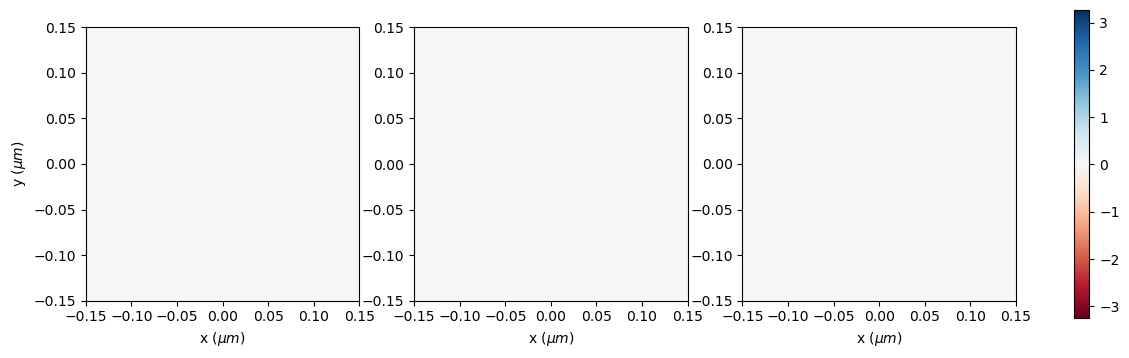

Saved animation: test.gif


In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter


fig, ax = plt.subplots(1,3, figsize = (15,8))
ims = []
comp = [0,1,4]

vmin = min(np.min(frames["xy"][c]) for c in comp)/vmax_cal
vmax = max(np.max(frames["xy"][c]) for c in comp)/vmax_cal
extent = [-sx/2, sx/2, -sy/2, sy/2]

def init():
    ims.append(ax[0].imshow(frames["xy"][0][0].T/vmax_cal, cmap = "RdBu", extent = extent, vmin=vmin, vmax=vmax, origin = "lower"))
    ims.append(ax[1].imshow(frames["xy"][1][0].T/vmax_cal, cmap = "RdBu", extent = extent, vmin=vmin, vmax=vmax, origin = "lower"))
    ims.append(ax[2].imshow(frames["xy"][4][0].T/vmax_cal, cmap = "RdBu", extent = extent, vmin=vmin, vmax=vmax, origin = "lower"))
    for axs in ax:
        axs.set_xlabel(r"x $(\mu m)$")
        axs.set_xlim(-.15, .15)
        axs.set_ylim(-.15, .15)
    ax[0].set_ylabel(r"y $(\mu m)$")
    fig.colorbar(ims[0], ax=ax, shrink = .5)


def update(i):
    for im,c in zip(ims,comp):
        im.set_data(frames["xy"][c][i].T)
    return ims


filename = "Nanoantenna_optical.gif"
ani = FuncAnimation(fig, update, frames=len(frames["t"]), init_func=init)

ani.save(filename, writer=PillowWriter(fps=15))
plt.show()
plt.close(fig)
print(f"Saved animation: {filename}")
